To analyze and visualize output

In [1]:
import pandas as pd, numpy as np
from itertools import combinations
from scipy.stats import spearmanr

# === Load your files ===
dms = pd.read_csv("../data/dms_le2.csv")[["sequence","fitness"]].rename(columns={"sequence":"seq"})
seed96 = pd.read_csv("../results/test5/STEP2_initial96.csv")[["sequence","fitness"]].rename(columns={"sequence":"seq"})
props1 = pd.read_csv("../results/test5/STEP5_bo_proposals_round1.csv")[["seq","mu","sigma","ei","hd_to_WT"]]
props2 = pd.read_csv("../results/test5/STEP5_bo_proposals_round2.csv")[["seq","mu","sigma","ei","hd_to_WT"]]
props3 = pd.read_csv("../results/test5/STEP5_bo_proposals_round3.csv")[["seq","mu","sigma","ei","hd_to_WT"]]
props4 = pd.read_csv("../results/test5/STEP5_bo_proposals_round4.csv")[["seq","mu","sigma","ei","hd_to_WT"]]
props5 = pd.read_csv("../results/test5/STEP5_bo_proposals_round5.csv")[["seq","mu","sigma","ei","hd_to_WT"]]
summ = pd.read_csv("../results/test5/summary_rounds_5.csv")

truth = dict(zip(dms["seq"], dms["fitness"]))

# === helpers ===
def y_of(seqs): return np.array([truth.get(s,np.nan) for s in seqs],dtype=float)

# === reconstruct round pools ===
measured_r0 = set(seed96["seq"])
pool_r1 = [s for s in dms["seq"] if s not in measured_r0]
sel_r1 = props1["seq"].tolist()
measured_r1 = measured_r0 | set(sel_r1)
pool_r2 = [s for s in dms["seq"] if s not in measured_r1]
sel_r2 = props2["seq"].tolist()
measured_r2 = measured_r1 | set(sel_r2)
pool_r3 = [s for s in dms["seq"] if s not in measured_r2]
sel_r3 = props3["seq"].tolist()
measured_r3 = measured_r2 | set(sel_r3)
pool_r4 = [s for s in dms["seq"] if s not in measured_r3]
sel_r4 = props4["seq"].tolist()
measured_r4 = measured_r3 | set(sel_r2)
pool_r5 = [s for s in dms["seq"] if s not in measured_r4]
sel_r5 = props5["seq"].tolist()

summ


,round,best_so_far,avg_selected,gain_best_vs_prev,gain_avg_vs_prevbest,diversity_mean_hamming,Hit@24,Hit@96,"Spearman(μ,true)",n_measured_total
0,1,0.808596,0.452216,0.036989,-0.319391,3.347826,0.0,0.0,-0.044348,120
1,2,0.817054,0.413254,0.008458,-0.395342,3.757246,0.0,0.0,0.048696,144
2,3,0.817054,0.427026,0.000000,-0.390028,3.605072,0.0,0.0,-0.118261,168
3,4,0.817054,0.228305,0.000000,-0.588748,3.826087,0.0,0.0,0.143478,192
4,5,0.817054,0.031077,0.000000,-0.785977,3.750000,0.0,0.0,-0.213913,216


In [2]:
print(dms['fitness'].mean())
print(dms['fitness'].max())
print(dms['fitness'].mode())

3.3523272598737353
4.11357579525
0    1.301030
1    1.301030
2    3.259355
3    3.693903
4    3.775974
Name: fitness, dtype: float64


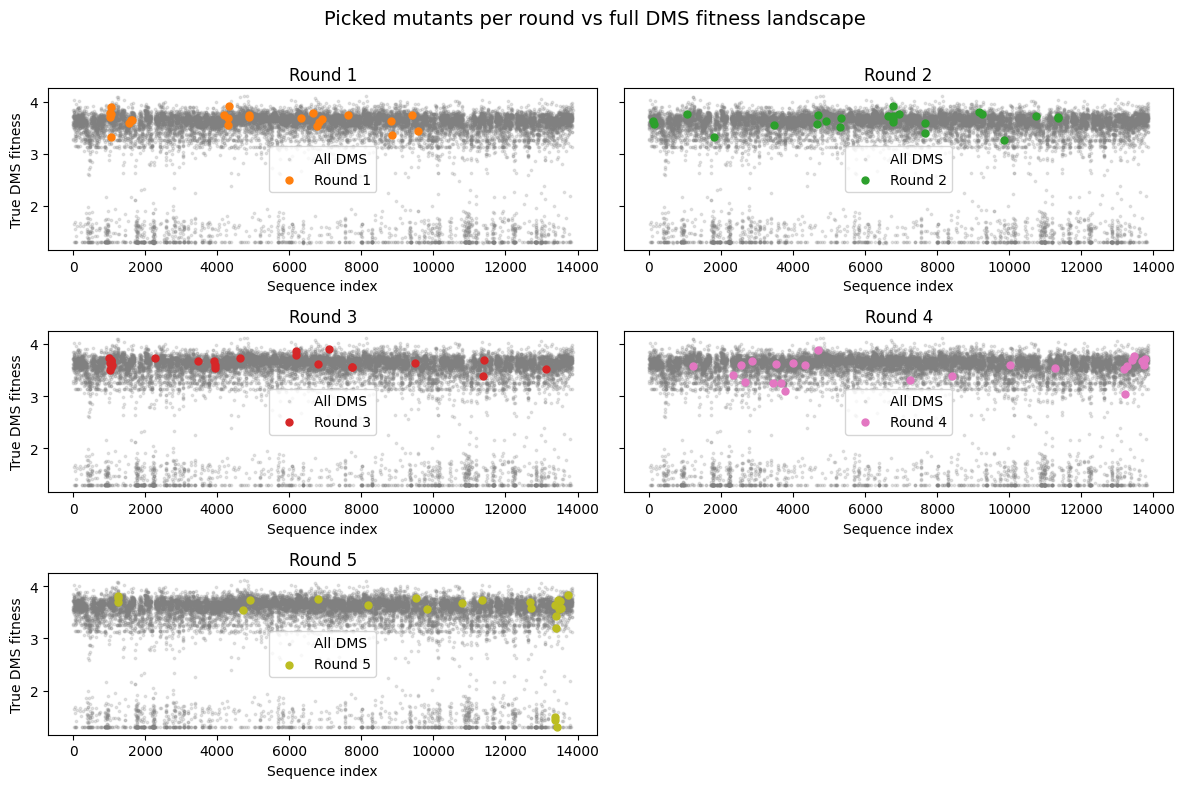

In [3]:
import matplotlib.pyplot as plt

rounds = [sel_r1, sel_r2, sel_r3, sel_r4, sel_r5]
colors = ["tab:orange", "tab:green", "tab:red", "tab:pink", "tab:olive"]

# Create a 3x2 grid (we'll hide the last empty subplot)
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()  # flatten 2D -> 1D for easy indexing

for i, (ax, sel, color) in enumerate(zip(axes, rounds, colors), 1):
    sel_idx = dms.index[dms["seq"].isin(sel)]
    ax.scatter(range(len(dms)), dms["fitness"], s=3, alpha=0.2, color="gray", label="All DMS")
    ax.scatter(sel_idx, dms.loc[sel_idx, "fitness"], color=color, s=25, label=f"Round {i}")
    ax.set_title(f"Round {i}")
    if i in [1, 3, 5]:  # left column
        ax.set_ylabel("True DMS fitness")
    ax.set_xlabel("Sequence index")
    ax.legend()

# Hide unused subplot (bottom right)
if len(axes) > len(rounds):
    for j in range(len(rounds), len(axes)):
        fig.delaxes(axes[j])

fig.suptitle("Picked mutants per round vs full DMS fitness landscape", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_8888\3149282464.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Round", y="Fitness", data=df_sel, palette="viridis")


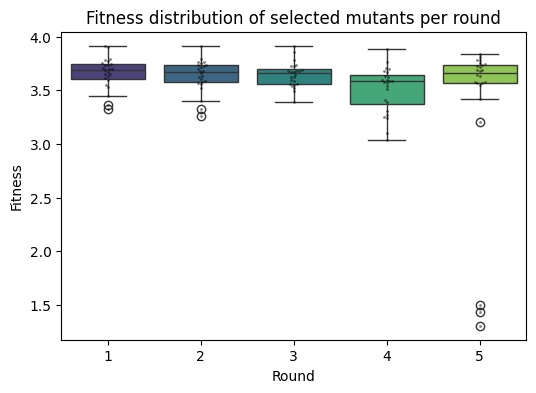

In [4]:
import seaborn as sns
import pandas as pd

sel_data = []
for i, sel in enumerate([sel_r1, sel_r2, sel_r3, sel_r4, sel_r5], 1):
    vals = dms.loc[dms["seq"].isin(sel), "fitness"]
    sel_data.append(pd.DataFrame({"Round": [i]*len(vals), "Fitness": vals}))

df_sel = pd.concat(sel_data)

plt.figure(figsize=(6,4))
sns.boxplot(x="Round", y="Fitness", data=df_sel, palette="viridis")
sns.swarmplot(x="Round", y="Fitness", data=df_sel, color="k", size=2, alpha=0.5)
plt.title("Fitness distribution of selected mutants per round")
plt.show()


In [5]:
# Combine proposals from all rounds
props_all = pd.concat([props1, props2, props3, props4, props5], ignore_index=True)

# Keep only seq + mu and remove duplicates (if the same seq appeared in multiple rounds)
pred_df = props_all[["seq", "mu"]].drop_duplicates(subset="seq").rename(columns={"mu": "pred_score"})

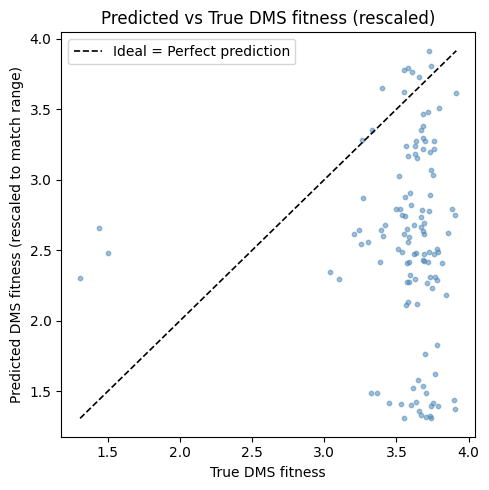

In [6]:
merged = dms.merge(pred_df, on="seq", how="inner")

pred_min, pred_max = merged["pred_score"].min(), merged["pred_score"].max()
fit_min, fit_max   = merged["fitness"].min(), merged["fitness"].max()

# Rescale predicted to same range as fitness
merged["pred_rescaled"] = (merged["pred_score"] - pred_min) / (pred_max - pred_min) * (fit_max - fit_min) + fit_min

plt.figure(figsize=(5,5))
plt.scatter(merged["fitness"], merged["pred_rescaled"], s=10, alpha=0.5, color="steelblue")
plt.plot([fit_min, fit_max], [fit_min, fit_max], 'k--', lw=1.2, label="Ideal = Perfect prediction")

plt.xlabel("True DMS fitness")
plt.ylabel("Predicted DMS fitness (rescaled to match range)")
plt.title("Predicted vs True DMS fitness (rescaled)")
plt.legend()
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Learning curve (GFP DMS simulation)')

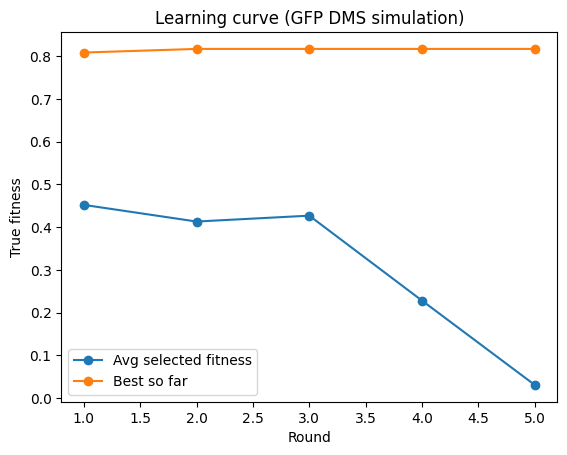

In [7]:
plt.figure()
plt.plot(summ["round"], summ["avg_selected"], marker="o", label="Avg selected fitness")
plt.plot(summ["round"], summ["best_so_far"], marker="o", label="Best so far")
plt.legend(); plt.xlabel("Round"); plt.ylabel("True fitness")
plt.title("Learning curve (GFP DMS simulation)")
